# GTSRB Traffic Sign Classification — ViT Fine-Tuning (RunPod, single GPU)

**v2 — reworked to fix the dataset problem.**

### Why this version exists

The Hugging Face copy of GTSRB (`bazyl/GTSRB`) stores images in parquet and
**throws away the original filenames**. That matters more than it sounds:
GTSRB encodes its *track* structure in the filename (`00000_00029.ppm` =
track 00000, frame 29). Each track is ~30 near-duplicate video frames of the
*same physical sign*. Without filenames, tracks can't be recovered — and
without tracks, a train/val split leaks near-duplicates across the split and
inflates validation accuracy. (That leak is exactly why the first run showed
88% val but only 71% on the official test set.)

So this notebook downloads the **original GTSRB archives** from the official
mirror, which keep the filenames — and therefore the tracks — intact.

### What changed vs. the first version

| Area | v1 | v2 |
|---|---|---|
| Data source | Kaggle (auth broke) / HF (filenames lost) | Official mirror, filenames intact |
| Track IDs | unrecoverable | parsed from real filenames |
| Val split | random (leaky) | **stratified track-aware** — every class in both splits, zero track leakage |
| Format | expects PNG | converts PPM → PNG once, in parallel |
| Pipeline | re-decodes every epoch | decode once + `cache()` |
| Unfreezing | guessed at layer names | robust block finder + verification |
| Results | saved to pod only | zipped for download |

### Run order
Top to bottom. Sections 3–4 are one-time (dataset prep); once done they're
skipped automatically on re-runs.


## 1. Environment check

In [1]:
pip install --upgrade keras keras-hub "tensorflow[and-cuda]" pandas scikit-learn seaborn matplotlib --break-system-packages

INFO: pip is looking at multiple versions of tensorflow-text to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of tensorflow-text to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 149.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.6/620.6 MB 7.8 MB/s eta 0:00:0000:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 4.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 23.3 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 20.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 32.6 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 12.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━

In [2]:
!nvidia-smi


Thu Jul 23 23:04:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.03             Driver Version: 580.159.03     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:41:00.0 Off |                  N/A |
| 30%   31C    P8             22W /  350W |       1MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### GPU smoke test — run this FIRST, before anything else

TensorFlow **does not work on Blackwell GPUs** (compute capability 12.0):
RTX 5090, RTX PRO 4000/4500/5000/6000 Blackwell, B200. The TF wheels ship no
sm_120 kernels, fall back to JIT-compiling from PTX, and that PTX is too old to
target Blackwell — so every GPU op dies with `CUDA_ERROR_INVALID_PTX`. This is
an open TensorFlow bug across 2.18–2.21, not something you can fix with a pip
install.

**Use an Ada or Ampere GPU instead:** RTX 4090, RTX 4000 Ada, L40S, L40, L4,
A100, A6000, A5000, A40, RTX 3090.

The cell below does a real GPU computation and fails immediately if the card is
unusable — costing you seconds instead of a dataset prep plus a training run.


In [3]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs visible:", gpus)
assert gpus, "No GPU detected — check the pod actually has a GPU attached."

# Report compute capability and warn on known-unsupported architectures.
details = tf.config.experimental.get_device_details(gpus[0])
cc = details.get("compute_capability")
print("Device name        :", details.get("device_name"))
print("Compute capability :", cc)

if cc is not None and cc[0] >= 12:
    print("\n*** WARNING: Blackwell-class GPU (sm_120). TensorFlow does not "
          "support this. Expect CUDA_ERROR_INVALID_PTX. Switch to an Ada or "
          "Ampere GPU (RTX 4090, L40S, A6000, A5000, A100, L4, 3090). ***")

# Actual GPU computation — this is what catches a broken architecture.
try:
    with tf.device("/GPU:0"):
        a = tf.random.normal((512, 512))
        b = tf.random.normal((512, 512))
        c = tf.matmul(a, b)
        result = float(tf.reduce_sum(c).numpy())
    print(f"\nGPU smoke test PASSED (checksum {result:.2f}) — safe to continue.")
except Exception as e:
    raise RuntimeError(
        "GPU smoke test FAILED — this GPU cannot run TensorFlow.\n"
        "If you see CUDA_ERROR_INVALID_PTX, the card is Blackwell (sm_120) and "
        "TensorFlow has no working kernels for it. Stop here, terminate this "
        "pod, and redeploy on an Ada/Ampere GPU (RTX 4090, L40S, A6000, A5000, "
        "A100, L4, 3090). Do not spend time trying to fix the CUDA install.\n\n"
        f"Original error: {e}"
    ) from e

# Single GPU on purpose: no MirroredStrategy. The dual-T4 setup caused the
# per-replica vs global batch size confusion and the optimizer-variable
# mismatch warnings on reload in the original notebook.


2026-07-23 23:04:10.675860: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0
Keras: 3.15.0
GPUs visible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Device name        : NVIDIA GeForce RTX 3090
Compute capability : (8, 6)


I0000 00:00:1784847854.590969     798 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22323 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:41:00.0, compute capability: 8.6



GPU smoke test PASSED (checksum 19229.07) — safe to continue.


## 2. Paths & hyperparameters

In [4]:
DATASET_PATH = "/workspace/data/gtsrb"          # where the prepared dataset will live
RAW_DIR = "/workspace/data/gtsrb_raw"           # where the official zips are downloaded/extracted

TRAIN_DIR = os.path.join(DATASET_PATH, "Train")
TEST_DIR = os.path.join(DATASET_PATH, "Test")
TEST_CSV_PATH = os.path.join(DATASET_PATH, "Test.csv")

OUTPUT_DIR = "/workspace/outputs/gtsrb_vit"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- Hyperparameters -------------------------------------------------------
NUM_CLASSES = 43
IMAGE_SIZE = 224            # required by the pretrained ViT preset
BATCH_SIZE = 128            # RTX PRO 4500 has 32GB — comfortable. Drop to 64 on OOM.

VAL_FRACTION = 0.2

# Phase 1: classifier head only (backbone frozen)
HEAD_EPOCHS = 8
HEAD_LR = 1e-3

# Phase 2: unfreeze the last N transformer blocks, fine-tune end-to-end
FINE_TUNE_EPOCHS = 15
FINE_TUNE_LR = 1e-5
UNFREEZE_LAST_N_BLOCKS = 4  # ViT-Base has 12 blocks

# Mixed precision roughly halves memory and can ~2x throughput on Ada GPUs.
# Left OFF by default because it can occasionally cause loss-scaling issues
# with from_logits losses, and a failed run costs more than a slower one.
# Once you have one clean successful run, try flipping this to True.
USE_MIXED_PRECISION = False

SEED = 123

if USE_MIXED_PRECISION:
    keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision policy:", keras.mixed_precision.global_policy().name)


## 3. Download the official GTSRB archives (one-time)

Source: the official mirror hosted by the University of Copenhagen (this is the
same archive `torchvision.datasets.GTSRB` downloads from). No login, no API
token, no Kaggle account needed.

Three archives:
- `GTSRB_Final_Training_Images.zip` (~263 MB) — training images, **filenames intact**
- `GTSRB_Final_Test_Images.zip` (~84 MB) — official test images
- `GTSRB_Final_Test_GT.zip` (~98 KB) — official test ground-truth labels


In [5]:
!apt-get update -qq && apt-get install -y -qq unzip wget


debconf: delaying package configuration, since apt-utils is not installed
(Reading database ... 24135 files and directories currently installed.)
Preparing to unpack .../wget_1.21.2-2ubuntu1.4_amd64.deb ...
Unpacking wget (1.21.2-2ubuntu1.4) over (1.21.2-2ubuntu1.1) ...
Selecting previously unselected package unzip.
Preparing to unpack .../unzip_6.0-26ubuntu3.2_amd64.deb ...
Unpacking unzip (6.0-26ubuntu3.2) ...
Setting up wget (1.21.2-2ubuntu1.4) ...
Setting up unzip (6.0-26ubuntu3.2) ...
Processing triggers for mailcap (3.70+nmu1ubuntu1) ...


In [6]:
BASE_URL = "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370"
ARCHIVES = [
    "GTSRB_Final_Training_Images.zip",
    "GTSRB_Final_Test_Images.zip",
    "GTSRB_Final_Test_GT.zip",
]

os.makedirs(RAW_DIR, exist_ok=True)

for name in ARCHIVES:
    dest = os.path.join(RAW_DIR, name)
    if os.path.exists(dest):
        print(f"Already downloaded: {name}")
        continue
    print(f"Downloading {name} ...")
    # -c resumes if interrupted, so a dropped connection doesn't restart the download
    !wget -c -q --show-progress -O {dest} {BASE_URL}/{name}

print()
!ls -lh {RAW_DIR}


Already downloaded: GTSRB_Final_Training_Images.zip
Already downloaded: GTSRB_Final_Test_Images.zip
Already downloaded: GTSRB_Final_Test_GT.zip

total 351M
-rw-rw-rw- 1 root root 369K Jan 18  2011 GT-final_test.csv
drwxrwxrwx 4 root root 2.0M Jul 15 01:33 GTSRB
-rw-rw-rw- 1 root root  98K May 10  2019 GTSRB_Final_Test_GT.zip
-rw-rw-rw- 1 root root  85M May 10  2019 GTSRB_Final_Test_Images.zip
-rw-rw-rw- 1 root root 264M May 10  2019 GTSRB_Final_Training_Images.zip


In [7]:
# Extract. Skipped automatically if already extracted.
train_marker = os.path.join(RAW_DIR, "GTSRB", "Final_Training", "Images")
test_marker = os.path.join(RAW_DIR, "GTSRB", "Final_Test", "Images")

if not os.path.isdir(train_marker):
    print("Extracting training images...")
    !unzip -q -o {RAW_DIR}/GTSRB_Final_Training_Images.zip -d {RAW_DIR}
else:
    print("Training images already extracted.")

if not os.path.isdir(test_marker):
    print("Extracting test images...")
    !unzip -q -o {RAW_DIR}/GTSRB_Final_Test_Images.zip -d {RAW_DIR}
else:
    print("Test images already extracted.")

print("Extracting test ground truth...")
!unzip -q -o {RAW_DIR}/GTSRB_Final_Test_GT.zip -d {RAW_DIR}

print()
print("Train images dir exists:", os.path.isdir(train_marker))
print("Test images dir exists: ", os.path.isdir(test_marker))
print()
print("Sample training filenames (note the track_frame structure):")
sample_class = sorted(os.listdir(train_marker))[0]
print(" ", sample_class, "->", sorted(os.listdir(os.path.join(train_marker, sample_class)))[:4])


Training images already extracted.
Test images already extracted.
Extracting test ground truth...

Train images dir exists: True
Test images dir exists:  True

Sample training filenames (note the track_frame structure):
  00000 -> ['00000_00000.ppm', '00000_00001.ppm', '00000_00002.ppm', '00000_00003.ppm']


## 4. Convert PPM → PNG (one-time)

The official archives ship `.ppm` images, which TensorFlow can't decode
natively. We convert once to PNG on disk (rather than decoding PPM through a
slow `tf.py_function` on every epoch), **preserving the original filenames** so
the track IDs survive.

This runs in parallel across all vCPUs. Output layout mirrors the familiar
Kaggle structure, so the rest of the notebook is source-agnostic:

```
/workspace/data/gtsrb/
  Train/00000/00000_00000.png ...
  Test/00000.png ...
  Test.csv                       # columns: Path, ClassId
```


In [8]:
import glob
import shutil
from multiprocessing import Pool, cpu_count
from PIL import Image
import pandas as pd
from tqdm import tqdm

RAW_TRAIN = os.path.join(RAW_DIR, "GTSRB", "Final_Training", "Images")
RAW_TEST = os.path.join(RAW_DIR, "GTSRB", "Final_Test", "Images")

def _convert(job):
    src, dst = job
    if os.path.exists(dst):
        return
    Image.open(src).convert("RGB").save(dst, "PNG")

def convert_all(jobs, desc):
    if not jobs:
        print(f"{desc}: nothing to do (already converted).")
        return
    with Pool(processes=cpu_count()) as pool:
        list(tqdm(pool.imap_unordered(_convert, jobs, chunksize=200),
                  total=len(jobs), desc=desc))

# ---- Training images -------------------------------------------------------
train_jobs = []
for class_dir in sorted(os.listdir(RAW_TRAIN)):
    src_class_path = os.path.join(RAW_TRAIN, class_dir)
    if not os.path.isdir(src_class_path):
        continue
    dst_class_path = os.path.join(TRAIN_DIR, class_dir)
    os.makedirs(dst_class_path, exist_ok=True)
    for fname in os.listdir(src_class_path):
        if not fname.lower().endswith(".ppm"):
            continue
        dst_name = os.path.splitext(fname)[0] + ".png"   # keeps 00000_00029 stem
        train_jobs.append((os.path.join(src_class_path, fname),
                           os.path.join(dst_class_path, dst_name)))

convert_all(train_jobs, "Train PPM->PNG")

# ---- Test images -----------------------------------------------------------
os.makedirs(TEST_DIR, exist_ok=True)
test_jobs = []
for fname in os.listdir(RAW_TEST):
    if not fname.lower().endswith(".ppm"):
        continue
    dst_name = os.path.splitext(fname)[0] + ".png"
    test_jobs.append((os.path.join(RAW_TEST, fname),
                      os.path.join(TEST_DIR, dst_name)))

convert_all(test_jobs, "Test PPM->PNG")

n_train = sum(len(files) for _, _, files in os.walk(TRAIN_DIR))
n_test = len([f for f in os.listdir(TEST_DIR) if f.endswith(".png")])
print(f"\nTrain images: {n_train}   (expected 39209)")
print(f"Test images:  {n_test}   (expected 12630)")


Test PPM->PNG: 100%|██████████| 12630/12630 [00:00<00:00, 19789.29it/s]



Train images: 39209   (expected 39209)
Test images:  12630   (expected 12630)


In [9]:
# ---- Build Test.csv from the official ground truth --------------------------
# GT-final_test.csv is semicolon-separated with columns:
# Filename;Width;Height;Roi.X1;Roi.Y1;Roi.X2;Roi.Y2;ClassId
gt_candidates = glob.glob(os.path.join(RAW_DIR, "**", "GT-final_test.csv"), recursive=True)
assert gt_candidates, "GT-final_test.csv not found — check the GT zip extracted correctly."
gt_path = gt_candidates[0]
print("Using ground truth:", gt_path)

gt = pd.read_csv(gt_path, sep=";")
print("Ground truth columns:", list(gt.columns))

test_df_out = pd.DataFrame({
    "Path": ["Test/" + os.path.splitext(f)[0] + ".png" for f in gt["Filename"]],
    "ClassId": gt["ClassId"].astype(int),
})
test_df_out.to_csv(TEST_CSV_PATH, index=False)

print(f"\nWrote {TEST_CSV_PATH}  ({len(test_df_out)} rows)")
print(test_df_out.head())

# Sanity: every referenced file must actually exist
missing = [p for p in test_df_out["Path"].head(50)
           if not os.path.exists(os.path.join(DATASET_PATH, p))]
assert not missing, f"Missing test images, e.g. {missing[:3]}"
print("\nSpot-check passed: test image paths resolve correctly.")


Using ground truth: /workspace/data/gtsrb_raw/GT-final_test.csv
Ground truth columns: ['Filename', 'Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId']

Wrote /workspace/data/gtsrb/Test.csv  (12630 rows)
             Path  ClassId
0  Test/00000.png       16
1  Test/00001.png        1
2  Test/00002.png       38
3  Test/00003.png       33
4  Test/00004.png       11

Spot-check passed: test image paths resolve correctly.


## 5. Stratified track-aware train/validation split

Filenames look like `00000_00029.png` inside class folder `00000`:
`{track}_{frame}`. All frames sharing a track are the *same physical sign*, so
they must never straddle the split.

We hold out `VAL_FRACTION` of **tracks within each class** (stratified), which:
- guarantees zero track leakage between train and val,
- guarantees all 43 classes appear in *both* splits (a plain global track
  shuffle drops rare classes out of val entirely),
- makes validation accuracy a genuine predictor of official test accuracy.


In [10]:
import re
import numpy as np

def list_gtsrb_train_files(train_dir):
    """DataFrame of (filepath, class_id, track_id) for every training image."""
    rows = []
    for class_dir in sorted(os.listdir(train_dir)):
        class_path = os.path.join(train_dir, class_dir)
        if not os.path.isdir(class_path):
            continue
        for fname in os.listdir(class_path):
            if not fname.lower().endswith(".png"):
                continue
            m = re.match(r"(\d+)_(\d+)", fname)
            if m is None:
                raise ValueError(
                    f"Filename '{fname}' has no track structure. The track-aware "
                    "split needs original GTSRB filenames — re-check Section 4."
                )
            rows.append({
                "filepath": os.path.join(class_path, fname),
                "class_id": int(class_dir),
                "track_id": f"{class_dir}_{m.group(1)}",
            })
    return pd.DataFrame(rows)

file_df = list_gtsrb_train_files(TRAIN_DIR)
print(f"Training images : {len(file_df)}")
print(f"Unique tracks   : {file_df['track_id'].nunique()}")
print(f"Classes         : {file_df['class_id'].nunique()}")
print(f"Mean frames/track: {len(file_df) / file_df['track_id'].nunique():.1f}")


Training images : 39209
Unique tracks   : 1307
Classes         : 43
Mean frames/track: 30.0


In [11]:
def stratified_track_split(df, val_frac, seed):
    """Hold out val_frac of tracks *within each class*."""
    rng = np.random.RandomState(seed)
    val_tracks = set()
    for class_id, grp in df.groupby("class_id"):
        tracks = np.array(sorted(grp["track_id"].unique()))
        tracks = tracks[rng.permutation(len(tracks))]
        k = max(1, int(round(len(tracks) * val_frac)))
        k = min(k, len(tracks) - 1)          # never take every track of a class
        val_tracks.update(tracks[:k])
    return val_tracks

val_tracks = stratified_track_split(file_df, VAL_FRACTION, SEED)
file_df["is_val"] = file_df["track_id"].isin(val_tracks)

train_df = file_df[~file_df["is_val"]].reset_index(drop=True)
val_df = file_df[file_df["is_val"]].reset_index(drop=True)

print(f"Train: {len(train_df)} images / {train_df['track_id'].nunique()} tracks / "
      f"{train_df['class_id'].nunique()} classes")
print(f"Val  : {len(val_df)} images / {val_df['track_id'].nunique()} tracks / "
      f"{val_df['class_id'].nunique()} classes  ({100*len(val_df)/len(file_df):.1f}%)")

# ---- Hard guarantees: fail loudly rather than train on a broken split -------
leaked = set(train_df["track_id"]) & set(val_df["track_id"])
assert not leaked, f"Track leakage detected: {list(leaked)[:5]}"
assert train_df["class_id"].nunique() == NUM_CLASSES, "Some classes missing from train!"
assert val_df["class_id"].nunique() == NUM_CLASSES, "Some classes missing from val!"
print("\nChecks passed: no track leakage, all 43 classes present in both splits.")


Train: 31379 images / 1046 tracks / 43 classes
Val  : 7830 images / 261 tracks / 43 classes  (20.0%)

Checks passed: no track leakage, all 43 classes present in both splits.


## 6. Input pipeline

`decode → cache → shuffle → resize → batch → augment → prefetch`

The `cache()` sits *after* decode but *before* resize on purpose. The raw GTSRB
images are tiny (15×15 to 250×250), so caching them costs ~100 MB of RAM and
means the 39k PNGs are decoded from disk **once** instead of every epoch.
Caching after the 224×224 resize would need ~23 GB, so we don't.


In [12]:
AUTOTUNE = tf.data.AUTOTUNE

def decode_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_png(img, channels=3)   # uint8, original small size
    return img, label

def resize_image(img, label):
    img = tf.image.resize(img, (IMAGE_SIZE, IMAGE_SIZE))   # float32, 0-255
    return img, label

def make_dataset(df, training, cache_name):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["filepath"].values, df["class_id"].values.astype("int32"))
    )
    ds = ds.map(decode_image, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()                       # in-RAM cache of small decoded images
    if training:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(resize_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    return ds

train_ds = make_dataset(train_df, training=True, cache_name="train")
val_ds = make_dataset(val_df, training=False, cache_name="val")
print("Pipelines built.")


Pipelines built.


## 7. Augmentation (training only)

Note the noise scale: images here are on a **0–255** range, so `stddev=5.0` is
~2% of the range — a real but mild perturbation.

Rotation stays small (±~7°) on purpose: traffic signs have meaningful
orientation, and large rotations would fight the task.

`keras.layers.GaussianNoise` hard-enforces `0 <= stddev <= 1` in its
constructor — it assumes inputs are already normalised to `[0,1]`. Our pipeline
keeps images on their natural 0–255 scale (matching what the ViT preset
expects), so the built-in layer will reject any value we'd actually want here.
We use a small custom layer instead, which does the same thing without that
restriction.


In [ ]:
from keras import layers

class RandomGaussianNoise(layers.Layer):
    """GaussianNoise without Keras's built-in stddev<=1 restriction --
    our images are on a 0-255 scale, not the [0,1] scale that restriction assumes."""
    def __init__(self, stddev, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs, training=None):
        if training:
            noise = tf.random.normal(tf.shape(inputs), mean=0.0, stddev=self.stddev)
            return inputs + noise
        return inputs

data_augmentation = keras.Sequential(
    [
        layers.RandomBrightness(factor=0.2, value_range=(0, 255)),
        layers.RandomContrast(factor=0.2),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
        RandomGaussianNoise(stddev=5.0),
    ],
    name="data_augmentation",
)

# Applied after batching (cheaper), training=True so noise/rotation are active.
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE,
).prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)
print("Augmentation attached to train pipeline only.")


## 8. Phase 1 — classifier head only (backbone frozen)

Fast baseline. This is roughly where the original notebook stopped (~71% test),
because a linear probe on generic ImageNet features can't specialise to traffic
signs. Phase 2 is what actually fixes that.


In [ ]:
import keras_hub

model = keras_hub.models.ImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet",
    num_classes=NUM_CLASSES,
)

model.backbone.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=HEAD_LR),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

trainable = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
total = sum(int(np.prod(w.shape)) for w in model.weights)
print(f"Phase 1 trainable params: {trainable:,} / {total:,} "
      f"({100*trainable/total:.2f}%)")


In [ ]:
phase1_ckpt = os.path.join(OUTPUT_DIR, "phase1_head_best.keras")

callbacks_phase1 = [
    keras.callbacks.ModelCheckpoint(
        phase1_ckpt, monitor="val_accuracy", save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True, verbose=1
    ),
]

print("Phase 1: training classifier head only...\n")
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks_phase1,
)


## 9. Phase 2 — unfreeze the last N blocks and fine-tune

This is the change that should move the result from ~71% into the high 90s.

`ViTBackbone` is built with Keras's Functional API, so its named sub-layers
(`vit_patching_and_embedding`, `vit_encoder`) aren't Python attributes —
`model.backbone.encoder` doesn't exist. Reach them with `get_layer(...)`
instead. The transformer blocks themselves live inside the `ViTEncoder` layer
in a plain list attribute, `encoder_layers` (confirmed against the
`keras_hub` source: `ViTEncoder` is a `keras.layers.Layer`, not a `Model`, so
it has no public `.layers` property — only `Model` subclasses get that for
free).

One Keras subtlety worth knowing: a container layer with `trainable = False`
reports *no* trainable weights regardless of its children. So we can't freeze
the backbone and then unfreeze a nested block. Instead we set the backbone
trainable, then freeze the blocks we *don't* want.


In [ ]:
vit_encoder = model.backbone.get_layer("vit_encoder")
blocks = vit_encoder.encoder_layers

print(f"Found {len(blocks)} transformer blocks:")
for b in blocks:
    print("  -", b.name)

if not blocks:
    print("\n!! Could not identify transformer blocks automatically.")
    print("   This means keras_hub's internal ViTEncoder structure has changed")
    print("   from what this notebook expects. Inspect the summary below to")
    print("   find the correct attribute, and set `blocks` manually.")
    model.backbone.summary()
    raise RuntimeError("Transformer blocks not found — see backbone summary above.")


In [ ]:
before = sum(int(np.prod(w.shape)) for w in model.trainable_weights)

# Backbone container must be trainable for nested blocks to report weights.
model.backbone.trainable = True

# Freeze every block except the last N.
n_unfreeze = min(UNFREEZE_LAST_N_BLOCKS, len(blocks))
for b in blocks[:-n_unfreeze]:
    b.trainable = False
for b in blocks[-n_unfreeze:]:
    b.trainable = True

# Keep the patch/position embeddings frozen — they're generic and low-level.
for layer in model.backbone.layers:
    if any(k in layer.name.lower() for k in ("embedding", "patch")):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

after = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
total = sum(int(np.prod(w.shape)) for w in model.weights)
print(f"Unfroze last {n_unfreeze} of {len(blocks)} blocks.")
print(f"Trainable params: {before:,} -> {after:,}  ({100*after/total:.1f}% of {total:,})")
assert after > before, (
    "Trainable parameter count did not increase — the unfreeze silently failed. "
    "Do not train; investigate the block names printed above first."
)
print("Unfreeze verified.")


In [ ]:
phase2_ckpt = os.path.join(OUTPUT_DIR, "phase2_finetuned_best.keras")

callbacks_phase2 = [
    keras.callbacks.ModelCheckpoint(
        phase2_ckpt, monitor="val_accuracy", save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=4, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy", factor=0.5, patience=2, min_lr=1e-7, verbose=1
    ),
]

print("Phase 2: fine-tuning...\n")
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks_phase2,
)

final_model_path = os.path.join(OUTPUT_DIR, "gtsrb_vit_final.keras")
model.save(final_model_path)
print(f"\nFinal model saved: {final_model_path}")


## 10. Training curves

In [ ]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

history = {}
for key in history_phase1.history:
    history[key] = history_phase1.history[key] + history_phase2.history.get(key, [])

history_df = pd.DataFrame(history)
history_df.insert(0, "epoch", range(1, len(history_df) + 1))
history_df["phase"] = ["phase1"] * len(history_phase1.history["accuracy"]) + \
                      ["phase2"] * len(history_phase2.history["accuracy"])
history_csv = os.path.join(OUTPUT_DIR, "training_history.csv")
history_df.to_csv(history_csv, index=False)
print("History saved:", history_csv)

boundary = len(history_phase1.history["accuracy"]) - 0.5

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ["accuracy", "loss"]):
    ax.plot(history[metric], label=f"train {metric}", marker="o", ms=3)
    ax.plot(history[f"val_{metric}"], label=f"val {metric}", marker="o", ms=3)
    ax.axvline(boundary, color="gray", ls="--", lw=1, label="phase 2 starts")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    ax.set_title(metric.capitalize())
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
curves_path = os.path.join(OUTPUT_DIR, "training_curves.png")
plt.savefig(curves_path, dpi=150)
plt.show()
print("Plot saved:", curves_path)


## 11. Official test set evaluation

One canonical evaluation cell — the original notebook had three that disagreed
(70.13%, 3.74%, 71.15%), one of them literally commented `#wrong one`.

The classic GTSRB trap: Keras assigns label indices by sorting class folder
names **as strings**. With the official zero-padded folders (`00000`…`00042`)
string order happens to match numeric order, so the mapping is the identity —
but we build it explicitly anyway, so this stays correct if the folder naming
ever changes.

We evaluate the in-memory model (best weights already restored by
`EarlyStopping`), which sidesteps the optimizer-variable warnings the original
hit when reloading from disk.


In [13]:
#Loading the latest modelto derive analytics
model = keras.models.load_model("/workspace/outputs/gtsrb_vit/gtsrb_vit_final_v2.keras")
print("Loaded. Params:", model.count_params())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:431: UserWarning: `build()` was called on layer 'vi_t_image_classifier', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/saving/serialization_lib.py:791: UserWarning: `compile()` was not called as part of model loading because the model's `compile()` method is custom. All subclassed Models that have `compile()` overridden should also override `get_compile_config()` and `compile_from_config(config)`. Alternatively, you can call `compile()` manually after loading.
  instance.compile_from_config(compile_config)


Loaded. Params: 85831723


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 402 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# true ClassId -> Keras index
class_folders = sorted(
    d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))
)
label_mapping = {int(folder): idx for idx, folder in enumerate(class_folders)}
inverse_mapping = {idx: int(folder) for idx, folder in enumerate(class_folders)}
print("Identity mapping?", all(k == v for k, v in label_mapping.items()))

test_df = pd.read_csv(TEST_CSV_PATH)
y_true = np.array([label_mapping[c] for c in test_df["ClassId"].values])
test_paths = [os.path.join(DATASET_PATH, p) for p in test_df["Path"]]
print(f"Test images: {len(test_paths)}")

test_ds = tf.data.Dataset.from_tensor_slices(test_paths)
test_ds = test_ds.map(lambda p: decode_image(p, 0)[0], num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(lambda img: tf.image.resize(img, (IMAGE_SIZE, IMAGE_SIZE)),
                      num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("\nRunning inference on the official test set...")
raw_logits = model.predict(test_ds, verbose=1)
y_pred = np.argmax(raw_logits, axis=1)

test_accuracy = accuracy_score(y_true, y_pred)
print("\n" + "=" * 52)
print(f"  OFFICIAL GTSRB TEST ACCURACY: {test_accuracy * 100:.2f}%")
print("=" * 52)

report = classification_report(
    y_true, y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=[f"class_{inverse_mapping[i]}" for i in range(NUM_CLASSES)],
    digits=4,
    zero_division=0,
)
report_path = os.path.join(OUTPUT_DIR, "classification_report.txt")
with open(report_path, "w") as f:
    f.write(f"Official GTSRB test accuracy: {test_accuracy * 100:.2f}%\n")
    f.write(f"Test images: {len(y_true)}\n\n")
    f.write(report)
print("\nReport saved:", report_path)
print(report)


Identity mapping? True
Test images: 12630

Running inference on the official test set...


2026-07-23 23:07:09.669492: I external/local_xla/xla/service/service.cc:163] XLA service 0x7242ac002860 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-23 23:07:09.669534: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-07-23 23:07:09.816379: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-23 23:07:10.195259: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92500
2026-07-23 23:07:11.280133: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-23 23:07:12.731223: I e

 1/99 ━━━━━━━━━━━━━━━━━━━━ 15:24 9s/step

I0000 00:00:1784848037.085129    1740 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


98/99 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step

2026-07-23 23:07:40.637672: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-07-23 23:07:41.732010: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_73', 8 bytes spill stores, 8 bytes spill loads

2026-07-23 23:07:41.755611: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4547', 16 bytes spill stores, 16 bytes spill loads

2026-07-23 23:07:42.028895: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 8 bytes spil

99/99 ━━━━━━━━━━━━━━━━━━━━ 37s 285ms/step

  OFFICIAL GTSRB TEST ACCURACY: 91.08%

Report saved: /workspace/outputs/gtsrb_vit/classification_report.txt
              precision    recall  f1-score   support

     class_0     0.9211    0.5833    0.7143        60
     class_1     0.8958    0.9431    0.9188       720
     class_2     0.9012    0.9360    0.9182       750
     class_3     1.0000    0.7356    0.8476       450
     class_4     0.9362    0.9788    0.9570       660
     class_5     0.8405    0.9032    0.8707       630
     class_6     1.0000    0.8133    0.8971       150
     class_7     0.9835    0.9244    0.9530       450
     class_8     0.9461    0.9356    0.9408       450
     class_9     0.9160    1.0000    0.9562       480
    class_10     0.9909    0.9879    0.9894       660
    class_11     0.8870    0.9905    0.9359       420
    class_12     0.9971    0.9957    0.9964       690
    class_13     0.9917    0.9931    0.9924       720
    class_14     0.9963    1.0000    

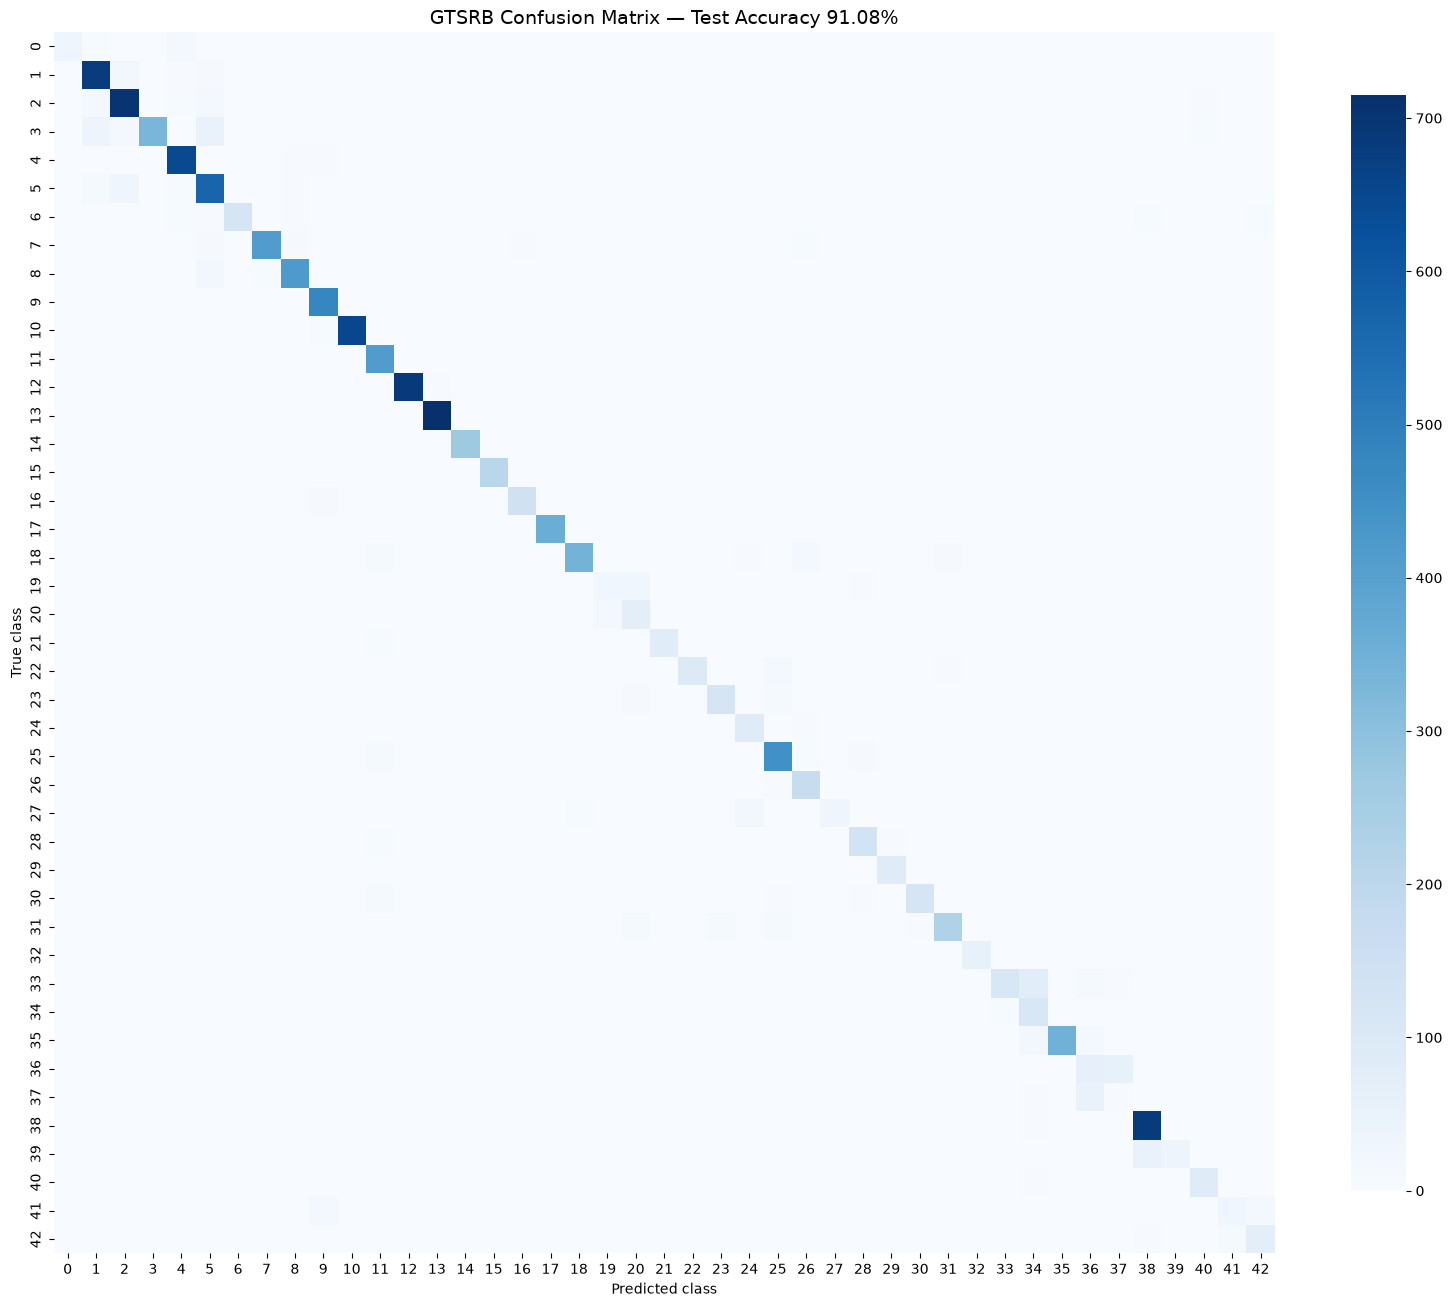

Confusion matrix saved: /workspace/outputs/gtsrb_vit/confusion_matrix.png

Top 10 confusions (true -> predicted, count):
  class 33 -> class 34 : 79
  class 36 -> class 37 : 57
  class 37 -> class 36 : 52
  class  3 -> class  5 : 52
  class 39 -> class 38 : 51
  class  3 -> class  1 : 38
  class  5 -> class  2 : 34
  class 19 -> class 20 : 27
  class  1 -> class  2 : 25
  class 35 -> class 34 : 22


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap="Blues", square=True, cbar_kws={"shrink": 0.8})
plt.title(f"GTSRB Confusion Matrix — Test Accuracy {test_accuracy*100:.2f}%", fontsize=14)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print("Confusion matrix saved:", cm_path)

# Most-confused pairs — useful material for the dissertation discussion
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
pairs = np.dstack(np.unravel_index(np.argsort(-cm_offdiag, axis=None), cm.shape))[0][:10]
print("\nTop 10 confusions (true -> predicted, count):")
for t, p in pairs:
    if cm_offdiag[t, p] > 0:
        print(f"  class {inverse_mapping[t]:>2} -> class {inverse_mapping[p]:>2} : {cm_offdiag[t, p]}")


## 12. Per-image predictions (dissertation appendix)

In [16]:
probs = tf.nn.softmax(raw_logits.astype("float32"), axis=1).numpy()

predictions_df = pd.DataFrame({
    "filename": test_df["Path"],
    "true_class_id": test_df["ClassId"],
    "predicted_class_id": [inverse_mapping[p] for p in y_pred],
    "confidence_pct": probs.max(axis=1) * 100,
    "correct": y_true == y_pred,
})
pred_csv = os.path.join(OUTPUT_DIR, "test_predictions.csv")
predictions_df.to_csv(pred_csv, index=False)

print("Predictions saved:", pred_csv)
print(f"Correct: {predictions_df['correct'].sum()} / {len(predictions_df)}")
print(f"Mean confidence when correct  : {predictions_df.loc[predictions_df['correct'], 'confidence_pct'].mean():.1f}%")
print(f"Mean confidence when incorrect: {predictions_df.loc[~predictions_df['correct'], 'confidence_pct'].mean():.1f}%")
predictions_df.head()


Predictions saved: /workspace/outputs/gtsrb_vit/test_predictions.csv
Correct: 11503 / 12630
Mean confidence when correct  : 96.5%
Mean confidence when incorrect: 69.1%


,filename,true_class_id,predicted_class_id,confidence_pct,correct
0,Test/00000.png,16,16,99.969627,True
1,Test/00001.png,1,1,99.999443,True
2,Test/00002.png,38,38,99.949898,True
3,Test/00003.png,33,34,50.255524,False
4,Test/00004.png,11,11,99.999146,True


## 13. Attention-map interpretability on mirror-pair failures

*Optional analysis, not required for the headline result — but genuinely
useful dissertation material.* The error analysis in Section 11 showed the
model's mistakes cluster in near-mirror-image sign pairs (e.g. "go straight
or left" vs. "go straight or right"). This section asks: **when the model
gets one of these wrong, is it even looking at the arrow, or is it looking
somewhere else entirely?**

ViT computes *attention* at every layer — how much each patch of the image
"looks at" every other patch, including a special *class token* that the
final decision is based on. `keras_hub` doesn't expose these scores through
its normal API, so this section manually replays the forward pass up to the
last transformer block and asks the underlying
`keras.layers.MultiHeadAttention` layer directly
(`return_attention_scores=True`). This was verified end-to-end against the
real `keras_hub` ViT source before being added here — see the notebook's
accompanying developer documentation for the source-level details.

**How to read the result:** if the attention heatmap lights up on the
arrow/pictogram itself, the model is looking in the right place but still
misreading direction (points toward augmentation being the problem — e.g.
rotation/zoom degrading a cue it already attends to). If the heatmap is
scattered elsewhere, the model isn't engaging with the distinguishing
feature at all (points toward needing more unfrozen capacity).


> **Preprocessing fix applied (see cell docstrings below).** `keras_hub`'s
> ViT preset attaches a real preprocessor (rescale + offset normalization)
> that `model.predict()`/`.fit()` apply automatically -- but a direct
> `model(x)` call or manual backbone walk does **not**. Earlier versions of
> the functions below skipped this, feeding the model raw 0-255 pixels it
> was never designed to receive that way. This was caught by noticing that
> control-group "correct" predictions showed near-zero confidence for their
> own true class -- inconsistent with the ~96.5% average confidence
> established from `test_predictions.csv` in Section 12 -- and confirmed by
> reading `keras_hub`'s source directly (`Task.preprocess_samples`,
> `ImageConverter`) rather than guessing.
>
> **What this means for results already collected:** Section 11 (the
> 91.08% result) is unaffected -- `model.predict()` was always correct.
> Section 13c (brightness check) is unaffected -- it never calls the
> model at all. **Sections 13, 13b, and 13d's numbers should be treated as
> unreliable until re-run** with the fix below; the underlying qualitative
> story may or may not hold once re-run correctly.


In [17]:
def get_last_layer_attention(model, image_batch1):
    """
    Runs one image through the ViT backbone manually, extracting the last
    transformer block's attention FROM the class token TO every patch
    (averaged across heads). This is the standard "where is the model
    looking when it makes its final decision" view.

    image_batch1: a (1, H, W, 3) float32 array, already resized to the
                  model's expected input size (0-255 range, matching how
                  this model was trained -- no extra normalization).

    IMPORTANT: keras_hub's ViT preset attaches a real preprocessor (rescale
    + offset) that model.predict()/.fit() apply automatically, but which a
    direct backbone/layer call does NOT. Skipping this step feeds the model
    raw, out-of-distribution pixel values and produces meaningless
    attention -- confirmed against keras_hub's source (Task.preprocess_samples
    / ImageConverter). Always route through model.preprocessor first.

    Returns: (attention_grid, n_patches_per_side)
    """
    if model.preprocessor is not None:
        image_batch1 = model.preprocessor(image_batch1)

    backbone = model.backbone
    patch_embed = backbone.get_layer("vit_patching_and_embedding")
    vit_encoder = backbone.get_layer("vit_encoder")
    blocks = vit_encoder.encoder_layers

    x = patch_embed(image_batch1)
    for b in blocks[:-1]:
        x = b(x)

    last_block = blocks[-1]
    x_normed = last_block.layer_norm_1(x)
    _, attn_scores = last_block.mha(x_normed, x_normed, return_attention_scores=True)
    # attn_scores: (1, num_heads, seq_len, seq_len); seq_len = num_patches + 1

    cls_to_patches = attn_scores[0, :, 0, 1:]                     # (num_heads, num_patches)
    cls_to_patches_avg = tf.reduce_mean(cls_to_patches, axis=0).numpy()

    n_side = int(round(np.sqrt(cls_to_patches_avg.shape[0])))
    grid = cls_to_patches_avg.reshape(n_side, n_side)
    return grid, n_side


def load_raw_image(path, image_size):
    """Loads and resizes an image the same way the test pipeline does."""
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (image_size, image_size))
    return img.numpy()


In [18]:
# Class-name lookup (verified against the official GTSRB signnames list)
CLASS_NAMES = {
    0: "Speed limit 20", 1: "Speed limit 30", 2: "Speed limit 50", 3: "Speed limit 60",
    4: "Speed limit 70", 5: "Speed limit 80", 9: "No passing", 19: "Dangerous curve left",
    20: "Dangerous curve right", 33: "Turn right ahead", 34: "Turn left ahead",
    36: "Go straight or right", 37: "Go straight or left", 38: "Keep right",
    39: "Keep left", 41: "End of no passing", 42: "End of no passing (>3.5t)",
}

# Known mirror-pair confusions from the error analysis (true_class, predicted_class)
TARGET_PAIRS = [(37, 36), (19, 20), (33, 34), (39, 38), (41, 9)]

examples = []
for true_c, pred_c in TARGET_PAIRS:
    mask = (y_true == true_c) & (y_pred == pred_c)
    idxs = np.where(mask)[0]
    if len(idxs) > 0:
        examples.append((idxs[0], true_c, pred_c))
        print(f"Found example: true={true_c} ({CLASS_NAMES.get(true_c,'?')}) "
              f"-> predicted={pred_c} ({CLASS_NAMES.get(pred_c,'?')})")
    else:
        print(f"No example found for true={true_c} -> predicted={pred_c} "
              f"(good sign -- or this model doesn't make that specific error)")

print(f"\nTotal examples to visualize: {len(examples)}")


Found example: true=37 (Go straight or left) -> predicted=36 (Go straight or right)
Found example: true=19 (Dangerous curve left) -> predicted=20 (Dangerous curve right)
Found example: true=33 (Turn right ahead) -> predicted=34 (Turn left ahead)
Found example: true=39 (Keep left) -> predicted=38 (Keep right)
Found example: true=41 (End of no passing) -> predicted=9 (No passing)

Total examples to visualize: 5


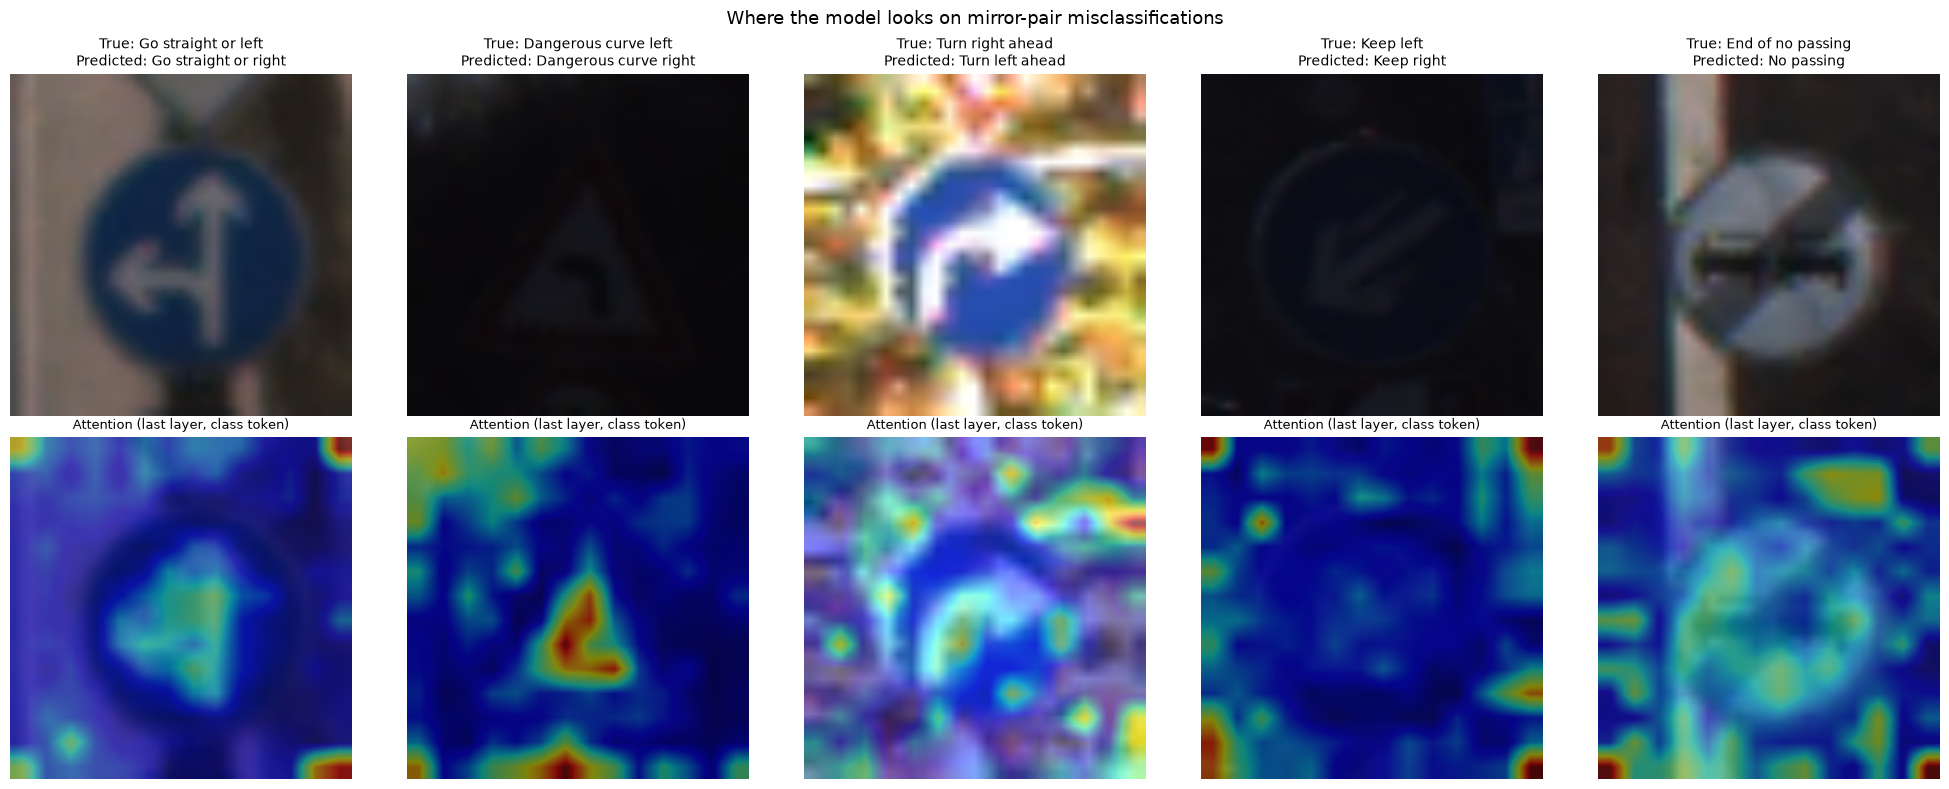

Saved: /workspace/outputs/gtsrb_vit/attention_maps_mirror_pairs.png


In [19]:
n = len(examples)
if n == 0:
    print("No mirror-pair misclassification examples found for this model -- skipping figure.")
else:
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    if n == 1:
        axes = axes.reshape(2, 1)

    for col, (idx, true_c, pred_c) in enumerate(examples):
        img_path = os.path.join(DATASET_PATH, test_df.iloc[idx]["Path"])
        img = load_raw_image(img_path, IMAGE_SIZE)
        img_batch = np.expand_dims(img, axis=0)

        grid, n_side = get_last_layer_attention(model, img_batch)

        attn_resized = tf.image.resize(
            grid[..., np.newaxis], (IMAGE_SIZE, IMAGE_SIZE), method="bilinear"
        ).numpy().squeeze()

        axes[0, col].imshow(img.astype("uint8"))
        axes[0, col].set_title(
            f"True: {CLASS_NAMES.get(true_c, true_c)}\n"
            f"Predicted: {CLASS_NAMES.get(pred_c, pred_c)}",
            fontsize=10,
        )
        axes[0, col].axis("off")

        axes[1, col].imshow(img.astype("uint8"))
        axes[1, col].imshow(attn_resized, cmap="jet", alpha=0.5)
        axes[1, col].set_title("Attention (last layer, class token)", fontsize=9)
        axes[1, col].axis("off")

    plt.suptitle("Where the model looks on mirror-pair misclassifications", fontsize=13)
    plt.tight_layout()
    attn_fig_path = os.path.join(OUTPUT_DIR, "attention_maps_mirror_pairs.png")
    plt.savefig(attn_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", attn_fig_path)


## 13b. Quantifying attention: left/right asymmetry

The qualitative heatmaps above are informative but easy to over-read by eye —
"attention looks centrally-weighted" isn't a number you can defend. This
section turns the same idea into an actual measurement.

**Why left/right asymmetry specifically:** four of the five confused pairs
(36/37, 33/34, 19/20, 38/39) are genuine left-right mirror images of each
other — the *only* thing that visually distinguishes them is which side an
arrow or curve points to. So instead of manually annotating a bounding box
around "the distinguishing stroke" in every image (subjective, and not
something that can be done without inspecting each image individually), we
compute a single well-defined number per image: how much more of the
model's attention mass falls on the right half of the image than the left
half. `(right_mass - left_mass) / total_mass`, verified against synthetic
grids to run from -1 (all attention left) to +1 (all attention right), 0 for
perfectly symmetric attention.

**The actual test:** if the model reliably resolves the left/right cue,
correctly-classified examples of a class and its mirror partner should show
a *clear, separated* difference in this score. If the model's confusion
comes from failing to resolve that cue, misclassified examples should sit
closer to the *wrong* class's typical score than the *true* class's — i.e.
the attention pattern itself already looks like the class the model guessed,
not the class the image actually is.

The 41/9 pair (End of no passing / No passing) is excluded here — it isn't a
left-right mirror pair, so this metric doesn't apply to it.


In [20]:
def attention_asymmetry(model, img_path_full, image_size):
    """(right attention mass - left attention mass) / total mass.
    Verified on synthetic grids: -1 = all-left, +1 = all-right, 0 = symmetric."""
    img = load_raw_image(img_path_full, image_size)
    img_batch = np.expand_dims(img, axis=0)
    grid, n_side = get_last_layer_attention(model, img_batch)
    left_half = grid[:, : n_side // 2].sum()
    right_half = grid[:, n_side // 2 :].sum()
    total = grid.sum()
    return float((right_half - left_half) / total)


def get_example_indices(y_true, y_pred, true_c, pred_c, max_n=15):
    mask = (y_true == true_c) & (y_pred == pred_c)
    return np.where(mask)[0][:max_n]


MIRROR_PAIRS = [(37, 36), (19, 20), (33, 34), (39, 38)]

rows = []
for class_a, class_b in MIRROR_PAIRS:
    groups = {
        f"{class_a} correct ({CLASS_NAMES.get(class_a, class_a)})": get_example_indices(y_true, y_pred, class_a, class_a),
        f"{class_b} correct ({CLASS_NAMES.get(class_b, class_b)})": get_example_indices(y_true, y_pred, class_b, class_b),
        f"{class_a}->{class_b} misclassified": get_example_indices(y_true, y_pred, class_a, class_b),
    }
    for label, idxs in groups.items():
        if len(idxs) == 0:
            print(f"  (no examples for: {label})")
            continue
        scores = [
            attention_asymmetry(model, os.path.join(DATASET_PATH, test_df.iloc[i]["Path"]), IMAGE_SIZE)
            for i in idxs
        ]
        rows.append({
            "pair": f"{class_a}/{class_b}",
            "group": label,
            "n": len(idxs),
            "mean_asymmetry": float(np.mean(scores)),
            "std_asymmetry": float(np.std(scores)),
        })
        print(f"  {label:<45} n={len(idxs):<3} mean={np.mean(scores):+.3f}  std={np.std(scores):.3f}")
    print()

asymmetry_df = pd.DataFrame(rows)
asymmetry_csv = os.path.join(OUTPUT_DIR, "attention_asymmetry.csv")
asymmetry_df.to_csv(asymmetry_csv, index=False)
print("Saved:", asymmetry_csv)


  37 correct (Go straight or left)              n=5   mean=-0.045  std=0.061
  36 correct (Go straight or right)             n=15  mean=-0.015  std=0.068
  37->36 misclassified                          n=15  mean=-0.093  std=0.082

  19 correct (Dangerous curve left)             n=15  mean=+0.005  std=0.055
  20 correct (Dangerous curve right)            n=15  mean=+0.013  std=0.089
  19->20 misclassified                          n=15  mean=-0.108  std=0.083

  33 correct (Turn right ahead)                 n=15  mean=-0.006  std=0.087
  34 correct (Turn left ahead)                  n=15  mean=-0.006  std=0.053
  33->34 misclassified                          n=15  mean=-0.016  std=0.067

  39 correct (Keep left)                        n=15  mean=-0.060  std=0.062
  38 correct (Keep right)                       n=15  mean=+0.006  std=0.077
  39->38 misclassified                          n=15  mean=-0.071  std=0.044

Saved: /workspace/outputs/gtsrb_vit/attention_asymmetry.csv


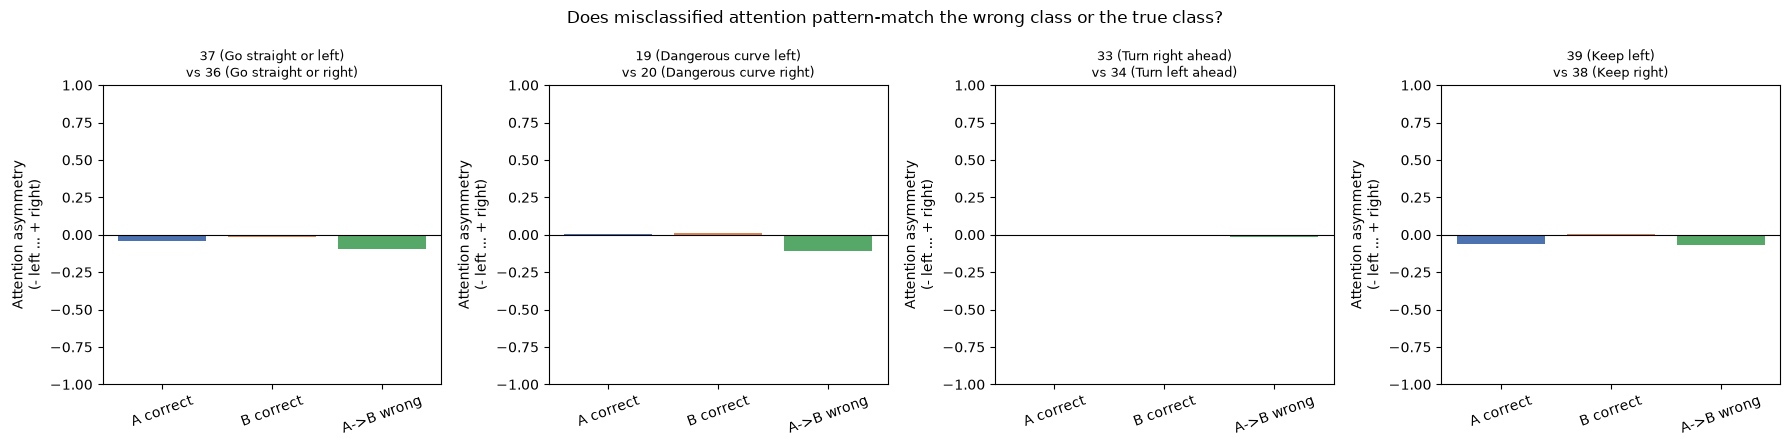

Saved: /workspace/outputs/gtsrb_vit/attention_asymmetry.png

Reading the chart: if the green bar (misclassified) sits closer to the
orange bar (wrong class) than the blue bar (true class), that's evidence
the model's attention pattern already 'looks like' the wrong class --
supporting the 'needs more capacity to resolve the cue' explanation over
'attention is just scattered/random' on these specific errors.


In [21]:
# Visualize: for each pair, are misclassified examples closer to the WRONG
# class's typical attention pattern than to the TRUE class's?
fig, axes = plt.subplots(1, len(MIRROR_PAIRS), figsize=(4.5 * len(MIRROR_PAIRS), 4.5))
if len(MIRROR_PAIRS) == 1:
    axes = [axes]

for ax, (class_a, class_b) in zip(axes, MIRROR_PAIRS):
    sub = asymmetry_df[asymmetry_df["pair"] == f"{class_a}/{class_b}"]
    if sub.empty:
        ax.set_visible(False)
        continue
    labels = ["A correct", "B correct", "A->B wrong"]
    means = []
    for lbl_key in [f"{class_a} correct", f"{class_b} correct", f"{class_a}->{class_b} misclassified"]:
        match = sub[sub["group"].str.startswith(lbl_key)]
        means.append(match["mean_asymmetry"].values[0] if not match.empty else np.nan)
    colors = ["#4C72B0", "#DD8452", "#55A868"]
    ax.bar(labels, means, color=colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylim(-1, 1)
    ax.set_title(f"{class_a} ({CLASS_NAMES.get(class_a,'?')})\nvs {class_b} ({CLASS_NAMES.get(class_b,'?')})", fontsize=9)
    ax.set_ylabel("Attention asymmetry\n(- left ... + right)")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Does misclassified attention pattern-match the wrong class or the true class?", fontsize=12)
plt.tight_layout()
asym_fig_path = os.path.join(OUTPUT_DIR, "attention_asymmetry.png")
plt.savefig(asym_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", asym_fig_path)
print()
print("Reading the chart: if the green bar (misclassified) sits closer to the")
print("orange bar (wrong class) than the blue bar (true class), that's evidence")
print("the model's attention pattern already 'looks like' the wrong class --")
print("supporting the 'needs more capacity to resolve the cue' explanation over")
print("'attention is just scattered/random' on these specific errors.")


## 13c. Follow-up: is image brightness driving some of these errors?

The asymmetry results in 13b split into two different patterns: on the
33/34 pair, misclassified attention cleanly resembled the wrong class's
normal pattern. On 19/20 and 39/38, misclassified attention was an outlier
relative to *both* classes' normal patterns -- not a clean mix-up between
two learned cues, but something closer to a breakdown. One plausible,
testable explanation: those specific misclassified images are simply
darker/lower-contrast than usual, degrading attention generally rather than
causing a specific left-right mix-up.

This check computes mean pixel brightness for the same groups used in 13b.
**If a pair's misclassified group is notably darker than its own correctly-
classified group, that's evidence for the "image quality" explanation. If
brightness is similar across groups, the anomaly in 13b needs a different
explanation.** Run across all four pairs, including 33/34 as a control --
if 33/34 does *not* show a brightness gap (as expected, since its errors
already looked like clean directional confusion), that strengthens the case
that 19/20 and 39/38 are a genuinely different failure mode, not the same
one measured slightly differently.


In [22]:
def mean_brightness(img_path_full, image_size):
    img = load_raw_image(img_path_full, image_size)
    return float(np.mean(img))

brightness_rows = []
for class_a, class_b in MIRROR_PAIRS:
    groups = {
        f"{class_a} correct": get_example_indices(y_true, y_pred, class_a, class_a),
        f"{class_a}->{class_b} misclassified": get_example_indices(y_true, y_pred, class_a, class_b),
    }
    for label, idxs in groups.items():
        if len(idxs) == 0:
            continue
        scores = [
            mean_brightness(os.path.join(DATASET_PATH, test_df.iloc[i]["Path"]), IMAGE_SIZE)
            for i in idxs
        ]
        brightness_rows.append({
            "pair": f"{class_a}/{class_b}",
            "group": label,
            "n": len(idxs),
            "mean_brightness": float(np.mean(scores)),
            "std_brightness": float(np.std(scores)),
        })

brightness_df = pd.DataFrame(brightness_rows)
brightness_csv = os.path.join(OUTPUT_DIR, "brightness_check.csv")
brightness_df.to_csv(brightness_csv, index=False)
print(brightness_df.to_string(index=False))
print()
print("Saved:", brightness_csv)


 pair                group  n  mean_brightness  std_brightness
37/36           37 correct  5        70.369171        2.354638
37/36 37->36 misclassified 15        66.175964        7.160689
19/20           19 correct 15        60.931004        3.582608
19/20 19->20 misclassified 15        17.113293       11.296966
33/34           33 correct 15        97.316953       22.451914
33/34 33->34 misclassified 15       121.129333       28.193424
39/38           39 correct 15       131.171974       13.983850
39/38 39->38 misclassified 15        46.893533       57.867025

Saved: /workspace/outputs/gtsrb_vit/brightness_check.csv


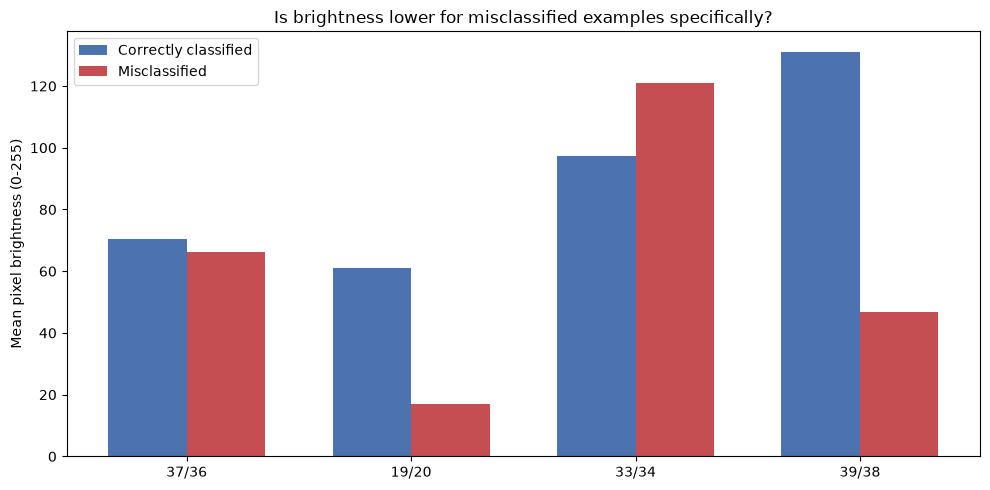

Saved: /workspace/outputs/gtsrb_vit/brightness_check.png


In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
pairs_list = [f"{a}/{b}" for a, b in MIRROR_PAIRS]
correct_vals = []
wrong_vals = []
for a, b in MIRROR_PAIRS:
    sub = brightness_df[brightness_df["pair"] == f"{a}/{b}"]
    c = sub[sub["group"] == f"{a} correct"]["mean_brightness"]
    w = sub[sub["group"] == f"{a}->{b} misclassified"]["mean_brightness"]
    correct_vals.append(c.values[0] if not c.empty else np.nan)
    wrong_vals.append(w.values[0] if not w.empty else np.nan)

x = np.arange(len(pairs_list))
width = 0.35
ax.bar(x - width/2, correct_vals, width, label="Correctly classified", color="#4C72B0")
ax.bar(x + width/2, wrong_vals, width, label="Misclassified", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(pairs_list)
ax.set_ylabel("Mean pixel brightness (0-255)")
ax.set_title("Is brightness lower for misclassified examples specifically?")
ax.legend()
plt.tight_layout()
brightness_fig_path = os.path.join(OUTPUT_DIR, "brightness_check.png")
plt.savefig(brightness_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", brightness_fig_path)


## 13d. Testing a fix: does contrast correction rescue the image-quality failures?

Section 13c showed 19/20 and 39/38's misclassified examples are dramatically
darker than their own correctly-classified counterparts (2.8-3.6x lower mean
brightness) -- while 33/34 showed no such pattern (if anything, the opposite).
That's a clean split: two pairs look like a genuine architectural confusion,
two pairs look like an image-quality problem.

This section runs the cheapest possible test of that theory: **using the
exact same trained model, no retraining at all**, apply a simple contrast
correction (per-image percentile-based rescaling, sometimes called "auto
contrast stretch") to the misclassified dark images, and check whether the
model now gets them right.

Two things are checked together, because a fix that isn't also checked for
side effects isn't a real fix:
- **Does correction rescue the misclassified images?** (the actual question)
- **Does correction break anything that was already correct?** (a control
  group of currently-correct predictions for the same classes, plus 33/34
  as an unrelated control -- if correction distorts *those*, it's not a
  safe intervention regardless of how well it fixes the target group)


In [24]:
def contrast_stretch(img, low_percentile=1, high_percentile=99):
    """Per-image percentile-based contrast stretch: rescales the image's
    own pixel value range to span the full 0-255. Percentiles (rather than
    raw min/max) make this robust to a few outlier pixels. Verified on
    synthetic dark/bright images before use: a genuinely underexposed image
    (mean ~20) gets stretched to a proper full-range image (mean ~125),
    while a well-exposed image is left roughly intact."""
    lo = np.percentile(img, low_percentile)
    hi = np.percentile(img, high_percentile)
    if hi <= lo:
        return img
    stretched = (img.astype(np.float32) - lo) / (hi - lo) * 255.0
    return np.clip(stretched, 0, 255).astype(np.float32)


def predict_single(model, img, label_mapping, inverse_mapping, true_class_id):
    """Runs one image through the model directly (not model.predict, since
    this is a single ad-hoc image, not a tf.data pipeline) and returns the
    predicted class, its confidence, and the probability assigned to the
    TRUE class specifically -- useful even when the prediction is still
    wrong, since it shows whether correction moved probability mass in the
    right direction even without flipping the final decision.

    img is on the RAW 0-255 scale. model.preprocessor is applied here,
    internally -- a direct model() call bypasses keras_hub's automatic
    preprocessing (confirmed against source), so skipping this step feeds
    the model out-of-distribution input and produces meaningless
    probabilities."""
    img_batch = np.expand_dims(img, axis=0).astype(np.float32)
    if model.preprocessor is not None:
        img_batch = model.preprocessor(img_batch)
    logits = model(img_batch, training=False).numpy()[0]
    probs = tf.nn.softmax(logits).numpy()
    pred_idx = int(np.argmax(probs))
    pred_class_id = inverse_mapping[pred_idx]
    true_idx = label_mapping[true_class_id]
    return {
        "pred_class_id": pred_class_id,
        "pred_confidence": float(probs[pred_idx]),
        "true_class_prob": float(probs[true_idx]),
    }


def evaluate_correction(model, img_path_full, image_size, true_class_id,
                        label_mapping, inverse_mapping):
    raw_img = load_raw_image(img_path_full, image_size)
    corrected_img = contrast_stretch(raw_img)
    before = predict_single(model, raw_img, label_mapping, inverse_mapping, true_class_id)
    after = predict_single(model, corrected_img, label_mapping, inverse_mapping, true_class_id)
    return raw_img, corrected_img, before, after


In [25]:
# Target group: misclassified examples from the two image-quality-driven pairs
TARGET_GROUPS = [(19, 20), (39, 38)]
# Control group: correctly-classified examples of the SAME classes, plus the
# 33/34 pair (which is NOT image-quality-driven) as an unrelated sanity check
CONTROL_CLASSES = [19, 20, 39, 38, 33, 34]

results_rows = []

print("=== TARGET: does correction fix currently-misclassified examples? ===\n")
for class_a, class_b in TARGET_GROUPS:
    idxs = get_example_indices(y_true, y_pred, class_a, class_b, max_n=15)
    fixed_count = 0
    for i in idxs:
        path = os.path.join(DATASET_PATH, test_df.iloc[i]["Path"])
        raw_img, corr_img, before, after = evaluate_correction(
            model, path, IMAGE_SIZE, class_a, label_mapping, inverse_mapping
        )
        fixed = (before["pred_class_id"] != class_a) and (after["pred_class_id"] == class_a)
        fixed_count += int(fixed)
        results_rows.append({
            "role": "target", "pair": f"{class_a}/{class_b}", "true_class": class_a,
            "before_pred": before["pred_class_id"], "before_true_prob": before["true_class_prob"],
            "after_pred": after["pred_class_id"], "after_true_prob": after["true_class_prob"],
            "fixed": fixed,
        })
    print(f"  {class_a}->{class_b} misclassified: {fixed_count}/{len(idxs)} fixed by contrast correction alone")

print("\n=== CONTROL: does correction break currently-correct predictions? ===\n")
for class_id in CONTROL_CLASSES:
    idxs = get_example_indices(y_true, y_pred, class_id, class_id, max_n=15)
    broken_count = 0
    for i in idxs:
        path = os.path.join(DATASET_PATH, test_df.iloc[i]["Path"])
        raw_img, corr_img, before, after = evaluate_correction(
            model, path, IMAGE_SIZE, class_id, label_mapping, inverse_mapping
        )
        broken = (before["pred_class_id"] == class_id) and (after["pred_class_id"] != class_id)
        broken_count += int(broken)
        results_rows.append({
            "role": "control", "pair": str(class_id), "true_class": class_id,
            "before_pred": before["pred_class_id"], "before_true_prob": before["true_class_prob"],
            "after_pred": after["pred_class_id"], "after_true_prob": after["true_class_prob"],
            "fixed": None, "broken": broken,
        })
    print(f"  class {class_id} correct: {broken_count}/{len(idxs)} broken by contrast correction")

correction_df = pd.DataFrame(results_rows)
correction_csv = os.path.join(OUTPUT_DIR, "contrast_correction_test.csv")
correction_df.to_csv(correction_csv, index=False)
print("\nSaved:", correction_csv)


=== TARGET: does correction fix currently-misclassified examples? ===

  19->20 misclassified: 12/15 fixed by contrast correction alone
  39->38 misclassified: 0/15 fixed by contrast correction alone

=== CONTROL: does correction break currently-correct predictions? ===

  class 19 correct: 0/15 broken by contrast correction
  class 20 correct: 1/15 broken by contrast correction
  class 39 correct: 0/15 broken by contrast correction
  class 38 correct: 0/15 broken by contrast correction
  class 33 correct: 3/15 broken by contrast correction
  class 34 correct: 0/15 broken by contrast correction

Saved: /workspace/outputs/gtsrb_vit/contrast_correction_test.csv


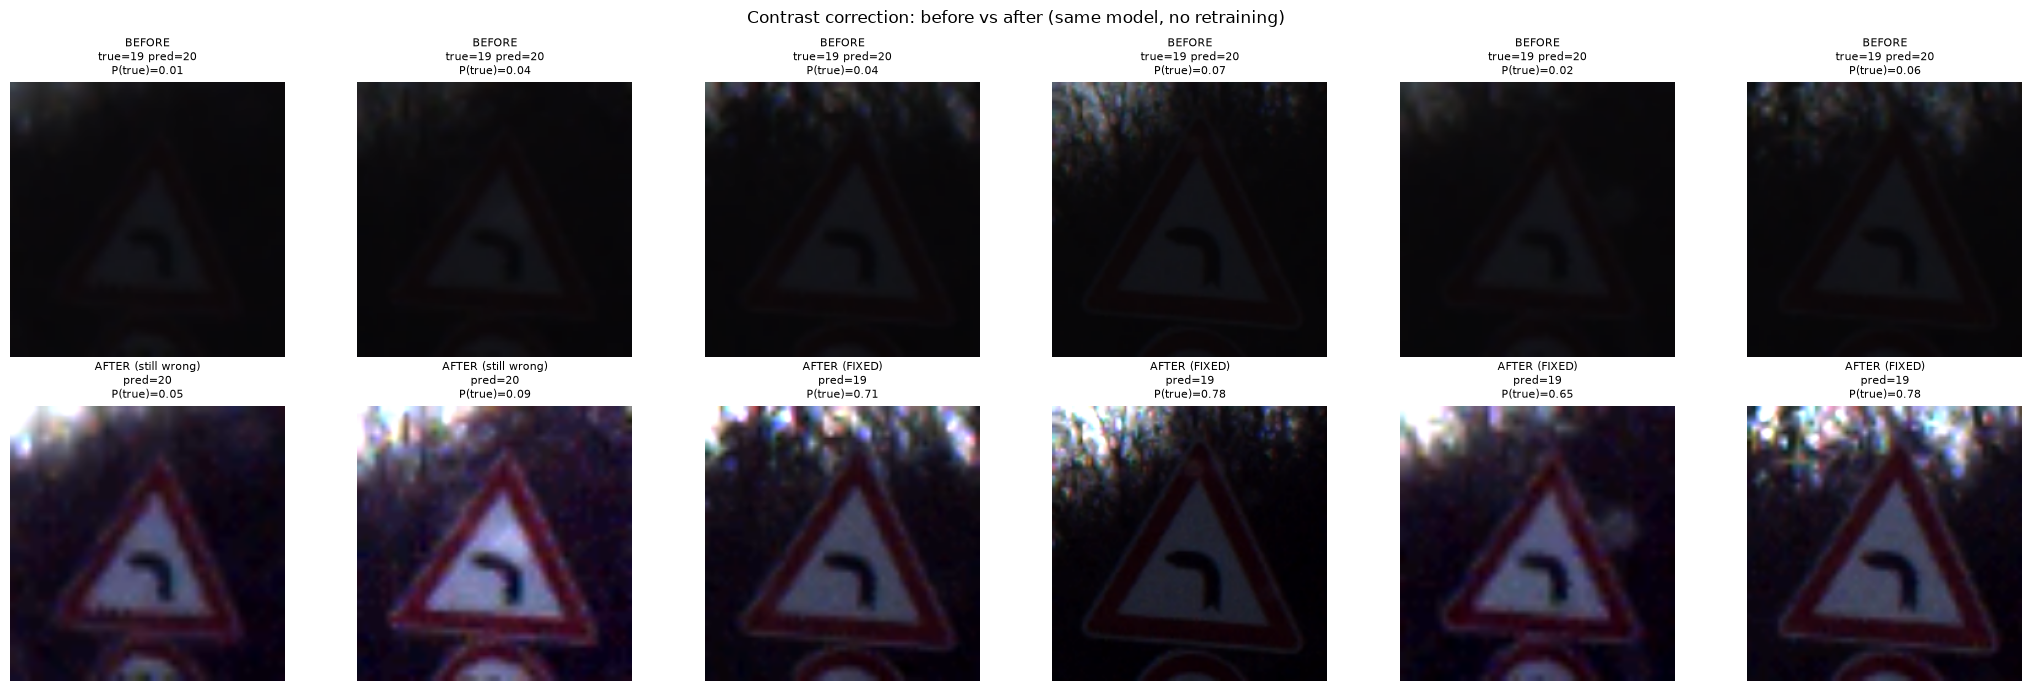

Saved: /workspace/outputs/gtsrb_vit/contrast_correction_examples.png


In [26]:
# Visualize a handful of target-group examples: original vs corrected, with
# the model's actual prediction and confidence at each stage.
n_show = min(6, len(correction_df[correction_df["role"] == "target"]))
target_rows = correction_df[correction_df["role"] == "target"].head(n_show)

fig, axes = plt.subplots(2, n_show, figsize=(3.5 * n_show, 7))
if n_show == 1:
    axes = axes.reshape(2, 1)

for col, (_, row) in enumerate(target_rows.iterrows()):
    idxs = get_example_indices(y_true, y_pred, row["true_class"],
                               int(row["pair"].split("/")[1]), max_n=15)
    i = idxs[col % len(idxs)]
    path = os.path.join(DATASET_PATH, test_df.iloc[i]["Path"])
    raw_img = load_raw_image(path, IMAGE_SIZE)
    corr_img = contrast_stretch(raw_img)

    axes[0, col].imshow(raw_img.astype("uint8"))
    axes[0, col].set_title(
        f"BEFORE\ntrue={row['true_class']} pred={row['before_pred']}\n"
        f"P(true)={row['before_true_prob']:.2f}", fontsize=8,
    )
    axes[0, col].axis("off")

    axes[1, col].imshow(corr_img.astype("uint8"))
    mark = "FIXED" if row["fixed"] else "still wrong"
    axes[1, col].set_title(
        f"AFTER ({mark})\npred={row['after_pred']}\n"
        f"P(true)={row['after_true_prob']:.2f}", fontsize=8,
    )
    axes[1, col].axis("off")

plt.suptitle("Contrast correction: before vs after (same model, no retraining)", fontsize=12)
plt.tight_layout()
correction_fig_path = os.path.join(OUTPUT_DIR, "contrast_correction_examples.png")
plt.savefig(correction_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", correction_fig_path)


**How to read this:**
- A high fix-rate on the target group with a near-zero break-rate on the
  control group would mean a simple, training-free preprocessing step
  meaningfully improves real-world reliability on these classes -- a strong,
  cheap, immediately actionable finding.
- A low fix-rate means the darkness isn't just hiding an otherwise-readable
  sign (the model may have already lost the information during the training
  it saw, or the sign truly isn't legible at any brightness) -- pointing
  instead toward fixing this at *training* time (e.g. adding brightness/
  contrast augmentation) rather than at inference time.
- Either result is a legitimate, reportable finding. Check `before_true_prob`
  vs `after_true_prob` in `contrast_correction_test.csv` even for examples
  that didn't flip to correct -- a meaningful increase without crossing the
  decision boundary still supports the underlying theory, just not strongly
  enough to change the final prediction on its own.


## 14. Download your results — **do this before stopping the pod**

Nothing leaves the pod automatically. Zip it, then download via the Jupyter file
browser (right-click → Download).


In [27]:
import shutil

zip_path = shutil.make_archive("/workspace/gtsrb_vit_results", "zip", OUTPUT_DIR)
print("Zipped:", zip_path, f"({os.path.getsize(zip_path)/1e6:.1f} MB)")
print()
print("Contents:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  {f:<40} {os.path.getsize(os.path.join(OUTPUT_DIR, f))/1e6:>8.1f} MB")
print()
print("Now: Jupyter file browser -> /workspace -> right-click")
print("'gtsrb_vit_results.zip' -> Download.")


Zipped: /workspace/gtsrb_vit_results.zip (3280.9 MB)

Contents:
  .ipynb_checkpoints                            1.0 MB
  attention_asymmetry.csv                       0.0 MB
  attention_asymmetry.png                       0.1 MB
  attention_maps_mirror_pairs.png               1.5 MB
  brightness_check.csv                          0.0 MB
  brightness_check.png                          0.0 MB
  classification_report.txt                     0.0 MB
  confusion_matrix.png                          0.1 MB
  contrast_correction_examples.png              1.2 MB
  contrast_correction_test.csv                  0.0 MB
  gtsrb_vit_final.keras                       570.9 MB
  gtsrb_vit_final_v2.keras                   1030.6 MB
  phase1_head_best.keras                      344.1 MB
  phase2_finetuned_best.keras                 570.9 MB
  phase3_continued_best.keras                1030.6 MB
  test_predictions.csv                          0.4 MB
  training_curves.png                           0.1 MB
 

In [28]:
import shutil, os

# Excludes model checkpoints (already have them offline) — keeps only
# reports, figures, and CSVs.
EXCLUDE = {
    "phase1_head_best.keras",
    "phase2_finetuned_best.keras",
    "gtsrb_vit_final.keras",
    "gtsrb_vit_final_v2.keras",
    "phase3_continued_best.keras",
}

light_dir = "/workspace/gtsrb_vit_results_light"
os.makedirs(light_dir, exist_ok=True)
for fname in os.listdir(OUTPUT_DIR):
    if fname in EXCLUDE:
        continue
    src = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(src):
        shutil.copy2(src, os.path.join(light_dir, fname))

zip_path = shutil.make_archive("/workspace/gtsrb_vit_results_light", "zip", light_dir)
print("Zipped:", zip_path, f"({os.path.getsize(zip_path)/1e6:.1f} MB)")
print()
print("Contents:")
for f in sorted(os.listdir(light_dir)):
    print(f"  {f:<45} {os.path.getsize(os.path.join(light_dir, f))/1e6:>8.2f} MB")
print()
print("Now: Jupyter file browser -> /workspace -> right-click")
print("'gtsrb_vit_results_light.zip' -> Download.")

Zipped: /workspace/gtsrb_vit_results_light.zip (954.3 MB)

Contents:
  attention_asymmetry.csv                           0.00 MB
  attention_asymmetry.png                           0.15 MB
  attention_maps_mirror_pairs.png                   1.49 MB
  brightness_check.csv                              0.00 MB
  brightness_check.png                              0.04 MB
  classification_report.txt                         0.00 MB
  confusion_matrix.png                              0.11 MB
  contrast_correction_examples.png                  1.18 MB
  contrast_correction_test.csv                      0.01 MB
  gtsrb_vit_final_v2.keras                       1030.59 MB
  test_predictions.csv                              0.44 MB
  training_curves.png                               0.11 MB
  training_history.csv                              0.00 MB

Now: Jupyter file browser -> /workspace -> right-click
'gtsrb_vit_results_light.zip' -> Download.


### Alternative: download over SCP

From your own machine, using the **SSH over exposed TCP** details on the pod's
Connect page (that's the one that supports file transfer — the other SSH line
doesn't):

```powershell
scp -P <port> -i "C:\Users\Ragul Aaryah\runpod-ssd-key" root@<pod-ip>:/workspace/gtsrb_vit_results.zip .
```


## 15. Notes

**GPU choice — this one actually bites.** TensorFlow has no working kernels for
Blackwell (sm_120): RTX 5090, RTX PRO 4000/4500/5000/6000 Blackwell, B200. It's
an open TF bug, not a config problem. Pick Ada or Ampere:

| Safe (Ada / Ampere) | VRAM | Broken (Blackwell) |
|---|---|---|
| RTX 4090 | 24 GB | RTX 5090 |
| RTX 4000 Ada | 20 GB | RTX PRO 4000 Blackwell |
| L40S / L40 | 48 GB | RTX PRO 4500 Blackwell |
| L4 | 24 GB | RTX PRO 5000/6000 Blackwell |
| A100 | 40/80 GB | B200 |
| A6000 / A5000 / A40 | 24–48 GB | |
| RTX 3090 | 24 GB | |

On RunPod these mostly sit under **"NVIDIA previous generation"** — that section
is the safe one here, despite the name. The Section 1 smoke test will catch a
bad card in seconds.

**Pod lifecycle.** `Stop` preserves the volume disk; `Terminate` deletes it.
Always Stop, never Terminate, until the results zip is on your own machine.

If a restart offers to *migrate* the pod, that's RunPod telling you someone else
took your original physical GPU while you were stopped. Migration copies your
data to a new machine and is safe, but you get a new pod ID and IP.

**What's already done and won't repeat.** Sections 3–4 (download + PPM→PNG) are
one-time and skip themselves on re-runs, as long as the volume survives. So
future experiments start straight at Section 5.

**If you hit OOM.** Drop `BATCH_SIZE` to 64, restart the kernel, re-run from
Section 2 (the dataset prep will skip itself).

**Possible next experiment.** If you want a second result for the dissertation,
a ViT-Small vs ViT-Base comparison is more interesting than going bigger:
"comparable accuracy at a fraction of the compute" is a stronger finding on a
near-saturated benchmark than "bigger model, no change". Change the preset in
Section 8 and re-run.
